In [5]:
import numpy as np

In [6]:
def swap_rows(A, i, j):
    A[[i,j]] = A[[j, i]]
    return A


In [7]:
M = np.array([
[1, 3, 6],
[0, -5, 2],
[-4, 5, 8]
])
print(M)

[[ 1  3  6]
 [ 0 -5  2]
 [-4  5  8]]


In [8]:
swap_rows(M, 0, 2)

array([[-4,  5,  8],
       [ 0, -5,  2],
       [ 1,  3,  6]])

In [9]:
M_swapped = swap_rows(M, 0, 2)
print(M_swapped)

[[ 1  3  6]
 [ 0 -5  2]
 [-4  5  8]]


In [10]:
M

array([[ 1,  3,  6],
       [ 0, -5,  2],
       [-4,  5,  8]])

In [11]:
M[:,1] # M[accessing rows, accessing columns]

array([ 3, -5,  5])

In [12]:
c = M[:, 2]

In [13]:
value = enumerate(c)

In [14]:
for i, j in value:
    print(f"Index: {i}, Value: {j}")

Index: 0, Value: 6
Index: 1, Value: 2
Index: 2, Value: 8


In [15]:
np.isclose(0.00001, 0, atol = 1e-5) # instead of checking if 6 == 0
# we check if 6 is close to 0 within a certain tolerance (1e-5 in this case)
# what is isclose()?
# isclose() is a function in the numpy library that checks if two values 
# are close to each other within a specified tolerance. It returns True if 
# the values are close and False otherwise. The function takes three parameters: 
# the first two are the values to compare, and the third is the absolute tolerance 
# (atol) which defines how close the values need to be to be considered equal.
# In the context of checking if a value is effectively zero, we can use 
# np.isclose(value, 0, atol=1e-5) to determine if the value is close enough to zero, 
# accounting for any small numerical inaccuracies that may arise in computations.

True

In [16]:
np.isclose(0.0001, 0, atol = 1e-5)

False

In [17]:
def first_nonzero_column(Mat, col, starting_row):
    col_values = Mat[starting_row:, col]

    for i, value in enumerate(col_values):
        if not np.isclose(value,0, atol = 1e-5):
            return i+starting_row # return the index of the first non-zero row in the specified column, starting from the given row index.
    return -1



In [18]:
M

array([[ 1,  3,  6],
       [ 0, -5,  2],
       [-4,  5,  8]])

In [19]:
N = np.array([
[0, 5, -3 ,6 ,8],
[0, 6, 3, 8, 1],
[0, 0, 0, 0, 0],
[0, 0, 0 ,0 ,7],
[0, 2, 1, 0, 4]
]
)
print(N)

[[ 0  5 -3  6  8]
 [ 0  6  3  8  1]
 [ 0  0  0  0  0]
 [ 0  0  0  0  7]
 [ 0  2  1  0  4]]


In [20]:
print(first_nonzero_column(N, 0, 0))

-1


In [21]:
print(first_nonzero_column(N, 4, 2)) # should return None since all values in the first column are zero

3


In [22]:
print(first_nonzero_column(N, 1, 2))

4


In [23]:
def first_nonzero_row(A, row, augmented = False):
    M = A.copy()
    if augmented:
        M = M[:, :-1] # Exclude the last column (augmented part)

    row_values = M[row, :]

    for i, value in enumerate(row_values):
        if not np.isclose(value, 0, atol = 1e-5):
            return i # return the index of the first non-zero column in the specified row.
    return -1


In [24]:
print(N)

[[ 0  5 -3  6  8]
 [ 0  6  3  8  1]
 [ 0  0  0  0  0]
 [ 0  0  0  0  7]
 [ 0  2  1  0  4]]


In [25]:
first_nonzero_row(N,2)

-1

In [26]:
first_nonzero_row(N, 3)

4

In [27]:
def augmented_matrix(A, B):
    augmented_M = np.hstack((A,B))
    return augmented_M

In [28]:
A = np.array([[1,2,3], [3,4,5], [4,5,6]])
B = np.array([[1], [5], [7]])

print(augmented_matrix(A, B))

[[1 2 3 1]
 [3 4 5 5]
 [4 5 6 7]]


In [29]:
A = np.array([[1,2,3],[0,1,0], [0,0,5]])
B = np.array([[1], [2], [4]])
augmented_M = augmented_matrix(A, B)

In [30]:
augmented_M

array([[1, 2, 3, 1],
       [0, 1, 0, 2],
       [0, 0, 5, 4]])

In [31]:
det_A = np.linalg.det(A)

In [32]:
det_A

4.999999999999999

In [33]:
if np.isclose(det_A, 0, atol = 1e-5):
    print("The matrix A is singular, and the system may have no solution or infinitely many solutions.")
else:
    print("The matrix A is non-singular, and the system has a unique solution.")

The matrix A is non-singular, and the system has a unique solution.


In [34]:
A = A.astype('float64')
B = B.astype('float64')

In [35]:
num_rows = A.shape[0]

In [46]:
M = augmented_matrix(A, B)

In [47]:
M

array([[1., 2., 3., 1.],
       [0., 1., 0., 2.],
       [0., 0., 5., 4.]])

In [48]:
num_rows = M.shape[0]

In [49]:
# Perform Gaussian elimination to convert the augmented matrix M into an upper triangular form
for row in range(num_rows):
    pivot_candidate = M[row, row]
    # The pivot candidate is the element in the current row and column that we are trying to use as a pivot for elimination.
    # If the pivot candidate is close to zero, we need to swap the current row with a row below it that has a non-zero value
    #  in the same column to ensure we have a valid pivot for elimination.
    if np.isclose(pivot_candidate, 0) == True:
       first_non_zero_value_below_pivot_candidate = first_nonzero_column(M, row, row)  

       M = swap_rows(M, row, first_non_zero_value_below_pivot_candidate)
       # After swapping, we need to update the pivot candidate to the new value in the current row and column. 
       pivot = M[row, row]

    else:# If the pivot candidate is not close to zero, we can proceed with the elimination process using the current pivot candidate.
        pivot = pivot_candidate
    # Normalize the current row by dividing it by the pivot element to make the pivot element equal to 1.
    M[row] = M[row] / pivot
    # After normalizing the current row, we need to eliminate the entries below the pivot in the same column 
    # by subtracting an appropriate multiple of the current row from the rows below it.
    for j in range(row+1, num_rows):
        value_below_pivot = M[j, row]
        M[j] = M[j] - value_below_pivot * M[row]


In [50]:
# Back substitution

M = M.copy()

num_rows = M.shape[0]   

for row in reversed(range(num_rows)):
    print(f"Row: {row}, M[row]: {M[row]}")

Row: 2, M[row]: [0.  0.  1.  0.8]
Row: 1, M[row]: [0. 1. 0. 2.]
Row: 0, M[row]: [1. 2. 3. 1.]


In [51]:
for row in reversed(range(num_rows)):
    substitution_row = M[row]
    index = first_nonzero_row(M, row, augmented=True)
    
    print(f"\n{'='*50}")
    print(f"OUTER LOOP → row = {row}")
    print(f"Substitution row: {substitution_row}")
    print(f"Pivot index (variable being solved): {index}")

    if index == -1:
        print(f"  → No pivot in row {row}, skipping.")
        continue

    for j in range(row):
        print(f"\n  INNER LOOP → j = {j} (eliminating variable {index} from row {j})")
        row_to_subtract_from = M[j]
        print(f"    Row {j} BEFORE: {row_to_subtract_from}")

        value = row_to_subtract_from[index]
        print(f"    Value to eliminate: M[{j}][{index}] = {value}")

        row_to_subtract_from = row_to_subtract_from - value * substitution_row
        M[j, :] = row_to_subtract_from
        print(f"    Row {j} AFTER:  {row_to_subtract_from}")

    print(f"\n  Matrix state after processing row {row}:")
    print(f"  {M}")


OUTER LOOP → row = 2
Substitution row: [0.  0.  1.  0.8]
Pivot index (variable being solved): 2

  INNER LOOP → j = 0 (eliminating variable 2 from row 0)
    Row 0 BEFORE: [1. 2. 3. 1.]
    Value to eliminate: M[0][2] = 3.0
    Row 0 AFTER:  [ 1.   2.   0.  -1.4]

  INNER LOOP → j = 1 (eliminating variable 2 from row 1)
    Row 1 BEFORE: [0. 1. 0. 2.]
    Value to eliminate: M[1][2] = 0.0
    Row 1 AFTER:  [0. 1. 0. 2.]

  Matrix state after processing row 2:
  [[ 1.   2.   0.  -1.4]
 [ 0.   1.   0.   2. ]
 [ 0.   0.   1.   0.8]]

OUTER LOOP → row = 1
Substitution row: [0. 1. 0. 2.]
Pivot index (variable being solved): 1

  INNER LOOP → j = 0 (eliminating variable 1 from row 0)
    Row 0 BEFORE: [ 1.   2.   0.  -1.4]
    Value to eliminate: M[0][1] = 2.0
    Row 0 AFTER:  [ 1.   0.   0.  -5.4]

  Matrix state after processing row 1:
  [[ 1.   0.   0.  -5.4]
 [ 0.   1.   0.   2. ]
 [ 0.   0.   1.   0.8]]

OUTER LOOP → row = 0
Substitution row: [ 1.   0.   0.  -5.4]
Pivot index (variabl

In [52]:
M

array([[ 1. ,  0. ,  0. , -5.4],
       [ 0. ,  1. ,  0. ,  2. ],
       [ 0. ,  0. ,  1. ,  0.8]])

In [53]:
print("Final solution (last column of M):")
print(M[:, -1])

Final solution (last column of M):
[-5.4  2.   0.8]


In [54]:
sol = np.linalg.solve(A, B)

In [55]:
print("Final solution (last column of M):")
print(sol)

Final solution (last column of M):
[[-5.4]
 [ 2. ]
 [ 0.8]]


In [56]:
v = np.array([[1],[3]])

In [ ]:
np.linalg.norm(v) # The norm of a vector is a measure of its length or magnitude.
#In the context of a vector v, np.linalg.norm(v) calculates the Euclidean norm 
# (also known as the L2 norm) of the vector, which is defined as the square root of the sum of the 
# squares of its components. For a vector v = [[1], [3]], the norm would be calculated as sqrt(1^2 + 3^2) = sqrt(10).

3.1622776601683795

In [66]:
x = [1, -2, -5]
y = [4, 3, -1]

In [67]:
for i, j in zip(x,y):
    print(f"i: {i}, j: {j}")

# i is the element from vector x and j is the corresponding element from vector y at the same index.
# The zip function pairs elements from the two vectors together, allowing us to iterate through both vectors simultaneously. In this case, the output will show the pairs of elements from x and y:
# i: 1, j: 4
# i: -2, j: 3
# i: -5, j: -1

i: 1, j: 4
i: -2, j: 3
i: -5, j: -1


In [ ]:
def dot(x,y):
    s = 0
    for i, j in zip(x,y):
        s +=i*j
    return s

dot(x,y) #1*4 + (-2)*3 + (-5)*(-1) = 4 - 6 + 5 = 3

3

In [60]:
# you can also use np.dot(x,y)
np.dot(x,y)

3

In [61]:
# for the dot product we can also do @
x @ y

TypeError: unsupported operand type(s) for @: 'list' and 'list'

In [ ]:
x = np.array([1, -2, -5])
y = np.array([4, 3, -1])
x@y #this is the fastest way to compute the dot product of two vectors in numpy, as it uses optimized linear algebra routines under the hood.

3

In [63]:
# the dot product of two orthogonal vectors is zero, meaning that they are perpendicular to each other in the vector space.
x = np.array([1, 0])
y = np.array([0, 1])
x @ y # The dot product of x and y is 0, which indicates that they are orthogonal (perpendicular) to each other in the 2D vector space.

0

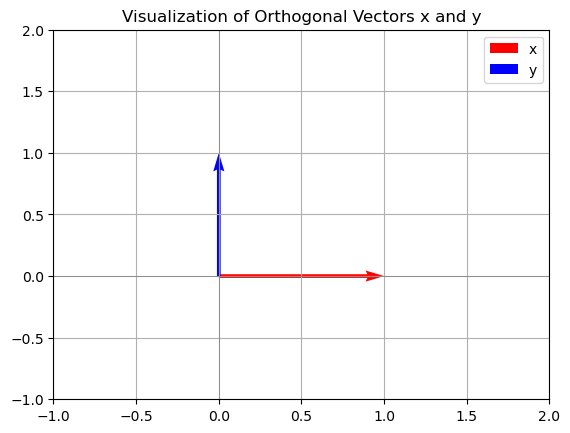

In [64]:
#plot the vectors x and y to visualize their orthogonality
import matplotlib.pyplot as plt
plt.quiver(0, 0, x[0], x[1], angles='xy', scale_units='xy', scale=1, color='r', label='x')
plt.quiver(0, 0, y[0], y[1], angles='xy', scale_units='xy', scale=1, color='b', label='y')
plt.xlim(-1, 2)
plt.ylim(-1, 2)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.grid()
plt.legend()
plt.title("Visualization of Orthogonal Vectors x and y")
plt.show()  